# 3. Trustworthy profiles

A CellProfiler run gives you a few thousand features, and most are redundant.
`AreaShape_Area` and `AreaShape_Perimeter` carry much the same information, and so does a
texture feature at scale 3 and the same texture at scale 5. Others are constant, or blow up
because they are ratios with a near-zero denominator.

Feature selection removes these. mantispy reproduces pycytominer's operations {cite:p}`Serrano_2025`, verified
feature by feature, because published pipelines depend on their precise behavior.

In [1]:
import matplotlib.pyplot as plt

import mantispy as mt

cells = mt.ds.synthetic_plate(
    n_plates=2,
    n_wells=96,
    n_cells=30,
    n_features=60,
    n_correlated_pairs=8,
    n_constant_features=4,
    effect_size=2.0,
    seed=0,
)
mt.pp.normalize(cells, by="Metadata_Plate", reference="negcon")
wells = mt.tl.aggregate(cells)
{"wells x features": wells.shape, "flagged degenerate_scale": int(wells.var["degenerate_scale"].sum())}

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_30363/2321282083.py:15: UserWarning: 4 of 68 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy(). Feature selection does not catch a feature that varies across a plate but is constant among its control wells.
  mt.pp.normalize(cells, by="Metadata_Plate", reference="negcon")


{'wells x features': (192, 68), 'flagged degenerate_scale': 4}

`normalize` warned and flagged four features in `var["degenerate_scale"]`. These are the
constant features the generator injected. They have no spread among the control wells, so
`mad_robustize` divides them by `epsilon = 1e-18` instead of by zero, as pycytominer does,
and they come back at around 1e17.

Here the variance threshold below removes them. It cannot catch a feature that varies across
the plate but is constant among the few control wells: feature selection measures variance
across all wells, keeps that feature, and it then dominates every distance computed
afterwards. Whenever `var["degenerate_scale"]` flags anything, drop those columns before
selecting:

```python
adata = adata[:, ~adata.var["degenerate_scale"].to_numpy()].copy()
```

On BBBC021 that is two features out of 473, and dropping them adds eight points of mechanism
retrieval (see [tutorial 6](06_mechanism_of_action.ipynb)).


The generator injected eight near-duplicate feature pairs and four constant features, so
we can check that selection removes them. `n_correlated_pairs=8` adds a partner for eight of
the features, so the object has 68 columns instead of the 60 requested, and every count below
is out of 68.

## Before

The correlation heatmap is ordered by feature group, with a line at each group boundary.
Blocks along the diagonal are families of features that measure nearly the same thing.

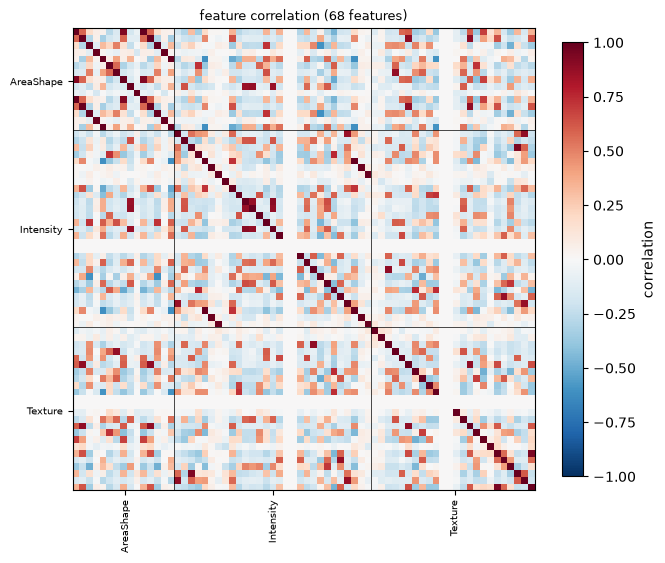

In [2]:
mt.pl.feature_correlation(wells, key=None)
plt.show()

## The operations

Each operation tests one criterion, and `feature_select` combines them. It does not drop
anything: it writes a boolean column to `var`, and only `subset_features` changes the shape,
so you can inspect what would be removed first.

| operation | drops a feature when |
| --- | --- |
| `variance_threshold` | its variance is below `min_variance` |
| `frequency_threshold` | one value dominates it, or it takes very few distinct values |
| `correlation_threshold` | it is highly correlated with another feature |
| `drop_na_columns` | too much of it is missing |
| `blocklist` | it is on the CellProfiler blocklist of known-unreliable features |
| `drop_outliers` | its magnitude has blown up |
| `noise_removal` | it varies too much between replicates of the same perturbation |

Two of these are easy to get wrong.

`variance_threshold` is a plain variance cut. The frequency-and-uniqueness rule often
described under that name is a separate operation, `frequency_threshold`, and its two
criteria combine with OR.

`correlation_threshold` uses the signed correlation, not the absolute value, so two
features correlated at −1.0 are both kept. pycytominer does the same, and mantispy matches
it.

In [3]:
for operation in ("variance_threshold", "correlation_threshold", "blocklist", "drop_na_columns"):
    trial = wells.copy()
    mt.pp.feature_select(trial, operations=(operation,))
    print(f"{operation:24s} keeps {int(trial.var['selected'].sum()):3d} of {trial.n_vars}")

variance_threshold       keeps  64 of 68
correlation_threshold    keeps  56 of 68
blocklist                keeps  68 of 68
drop_na_columns          keeps  68 of 68


`blocklist` and `drop_na_columns` keep everything here. The blocklist names real CellProfiler
features, and these synthetic ones are not on it. This generator call also injected no missing
values. On a real plate both remove features.

## Running the default pipeline

The default runs four of the seven operations. `frequency_threshold` and `drop_outliers` are
off because both can remove an informative feature on a screen with few conditions.
`noise_removal` is off because it needs replicate structure, which not every object has.

In [4]:
mt.pp.feature_select(wells)
wells.uns["mantispy"]["feature_select"]

{'variance_threshold': 4,
 'correlation_threshold': 12,
 'drop_na_columns': 0,
 'blocklist': 0}

In [5]:
survivors = set(wells.var_names[wells.var["selected"]])
constant = wells.uns["mantispy"]["truth"]["constant_features"]
pairs = wells.uns["mantispy"]["truth"]["correlated_pairs"]

{
    "constant features kept": [name for name in constant if name in survivors],
    "duplicate pairs left intact": [(a, b) for a, b in pairs if {a, b} <= survivors],
}

{'constant features kept': [], 'duplicate pairs left intact': []}

Every constant feature is gone, and no near-duplicate pair survived intact.

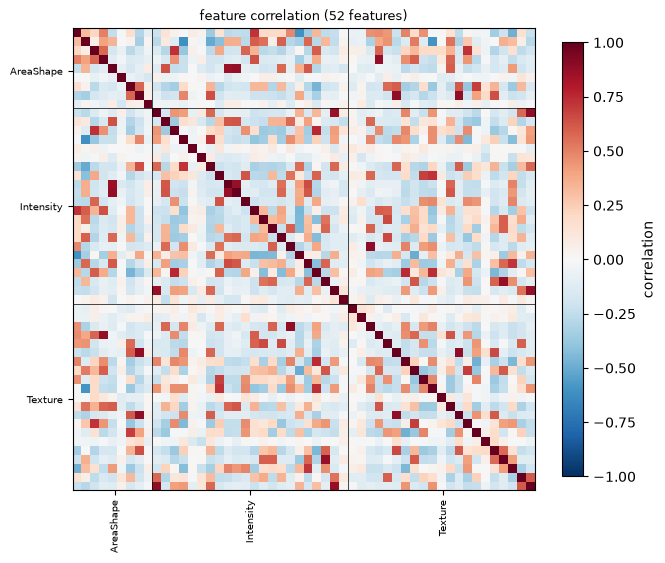

In [6]:
selected = mt.pp.subset_features(wells)
mt.pl.feature_correlation(selected, key=None)
plt.show()

The blocks are gone. `pl.feature_groups` shows which feature families lost features to
selection.

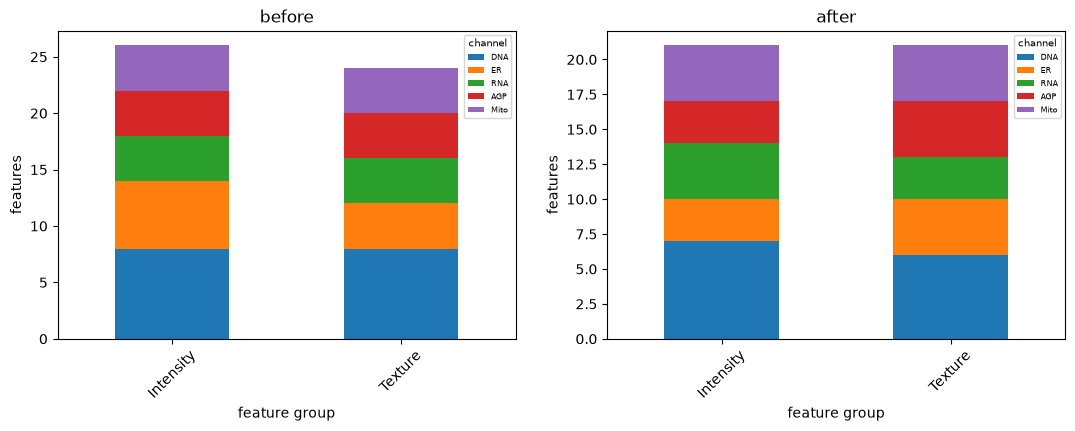

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
mt.pl.feature_groups(wells, ax=axes[0])
axes[0].set_title("before")
mt.pl.feature_groups(wells, key="selected", ax=axes[1])
axes[1].set_title("after")
plt.show()

### The blocklist

The default blocklist is pycytominer's, copied unchanged with its source recorded in the
file. It lists features known to be unreliable: twenty Manders and twenty rank-weighted
colocalization coefficients, plus the three highest granularity bands.
`MeasureColocalization` writes Manders, RWC and Costes coefficients, and only the first two
are on the list.

In [8]:
from mantispy._core.features import load_blocklist

blocked = load_blocklist()
len(blocked), blocked[:3]

(55,
 ['Nuclei_Correlation_Manders_AGP_DNA',
  'Nuclei_Correlation_Manders_AGP_ER',
  'Nuclei_Correlation_Manders_AGP_Mito'])

## Outlying cells

Feature selection cleans the columns, and outlier detection cleans the rows. Debris,
segmentation failures and out-of-focus cells all produce extreme but uninformative profiles.

There are three methods. Each produces a score where higher means more outlying, and all are
thresholded the same way, so `contamination` means the same thing for each.

- `ecod` has no parameters and is interpretable: a cell's score is the sum over features of
  how far into a tail it sits, so you can see which features made it an outlier.
- `isolation_forest` catches cells that are unusual in their combination of features without
  being extreme in any one.
- `mad` takes the largest robust z-score across features. It is simple to explain but looks
  at each feature on its own.

In [9]:
for method in ("ecod", "isolation_forest", "mad"):
    trial = cells.copy()
    mt.pp.outliers(trial, method=method, contamination=0.02)
    print(f"{method:18s} flagged {trial.obs['qc_outlier'].mean():.1%}")

ecod               flagged 2.0%


isolation_forest   flagged 2.0%
mad                flagged 2.0%


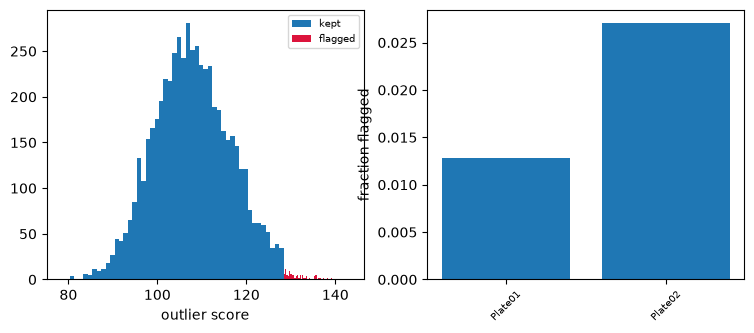

In [10]:
mt.pp.outliers(cells, method="ecod", contamination=0.02)
mt.pl.outliers(cells)
plt.show()

With `method="mad"` the score is a robust z-score, so `score_cutoff=5` applies the usual
"more than five robust standard deviations" rule instead of a fixed fraction.

## Diagnostics

Run these two plots before any correction. They show whether you need one.

`plate_effects` shows row and column marginals per plate. A position artifact appears as a
trend across rows or columns, while noise scatters around the plate median.

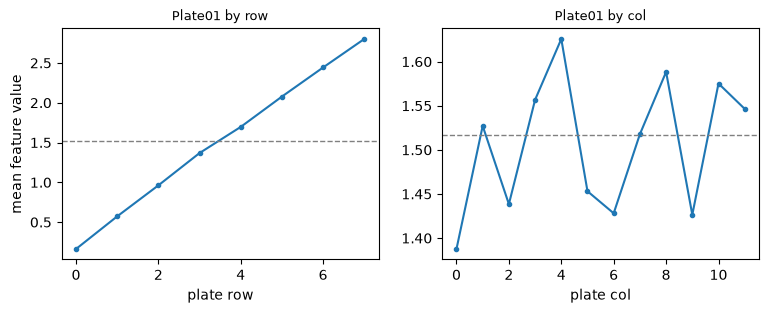

In [11]:
gradient = mt.ds.synthetic_plate(n_wells=96, n_cells=10, n_features=20, row_gradient=3.0, seed=0)
mt.pl.plate_effects(mt.tl.aggregate(gradient, min_cells=0))
plt.show()

`control_drift` projects the control wells onto components fitted on the controls alone.
If the controls of different plates land in different places, the reference itself shifts
between plates, which is what normalization should remove.

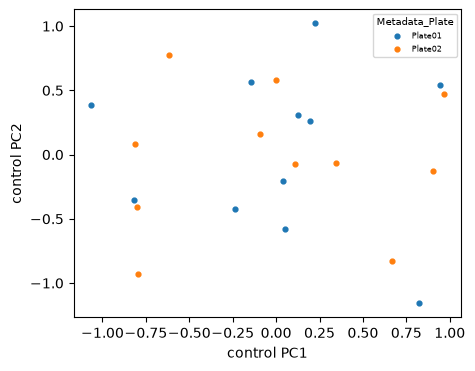

In [12]:
mt.pl.control_drift(wells, groupby="Metadata_Plate")
plt.show()

Next: [4. Correcting and evaluating](04_correcting_and_evaluating.ipynb), on removing these
artifacts and measuring whether that helped.